# TAM 2021-2026 Deep Analysis — CIT behaviour, SOR/EOR, cleaning recovery, Rf tracking

ตอบโจทย์วิศวกร (requirement F1) ด้วยข้อมูลจริง 2021-01 → 2026-07:

1. **CIT เต็มช่วง 2021-2026** พร้อมเส้น TAM/clean events — จุดที่ CIT ตกแรงสุดอยู่ตรงไหน
2. **SOR/EOR ต่อรอบการล้าง E113A** (กรอบเดียวกับสไลด์ Energy Saving Benefit ของโรงงาน:
   EOR 252°C → ล้าง → SOR 254°C, decay ~0.5°C/เดือน) — วัดจากข้อมูลจริงทุกGrade
3. **Event study:** การล้างครั้งไหน (HX ไหน) คืน CIT จริงเท่าไร — median CIT ก่อน/หลัง
   พร้อมรายงาน Δcharge คู่กันเพื่อกันการอ่านผิดจาก throughput เปลี่ยน
4. **Rf(t) fouling resistance ต่อ HX** — ตัวชี้วัด fouling มาตรฐาน (ไม่ผันตาม flow/อุณหภูมิรายวัน)
5. Export `dashboard/data/tam_analysis.json`

ทุก cell รันตามลำดับใน VSCode ได้ — ไม่มี hidden state.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()   # let matplotlib accept pd.Timestamp on date axes (avoids category-unit TypeError)
from pathlib import Path

from cpht_config import HX_CONFIG, CIT_TAG, TOTAL_CHARGE_TAG, CPHT_2_HX
from cpht_features import get_tam_dates

DATA = Path(os.environ.get('CPHT_DATA_DIR', r'C:\Desktop\Bangchak Internship 2026\Data'))
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG  = REPO / 'figures' / 'tam_analysis'; FIG.mkdir(parents=True, exist_ok=True)
OUT  = REPO / 'dashboard' / 'data' / 'tam_analysis.json'

feat = pd.read_csv(DATA / 'Feature_calculated.csv', parse_dates=['Timestamp']).set_index('Timestamp')
proc = pd.read_csv(DATA / 'Process_information_cleaned.csv', parse_dates=['Timestamp']).set_index('Timestamp')
cit    = proc[CIT_TAG]
charge = proc[TOTAL_CHARGE_TAG]
TAM_DATES = get_tam_dates()
print(f'data {feat.index.min().date()} -> {feat.index.max().date()} ({len(feat)} days)')
print('plant-wide TAM detected:', [str(d.date()) for d in TAM_DATES])

data 2021-01-01 -> 2026-07-01 (1898 days)
plant-wide TAM detected: ['2021-03-25', '2024-06-14']


## 1) CIT 2021-2026 เต็มช่วง + เหตุการณ์ล้างทั้งหมด

เส้นดำ = CIT (`1TI116.pv`) · เส้นเทา = charge (แกนขวา — ดูคู่กันเพื่อไม่อ่าน CIT ผิดตอน
throughput เปลี่ยน) · แถบแดง = plant-wide TAM · เส้นตั้งม่วง = การสลับเชลล์/ล้าง E113A↔E112C
(HX ตัวสุดท้ายก่อนเตา — cold_out ของมันคือ CIT โดยตรง จึงเป็นตัวกำหนดรอบ SOR/EOR)

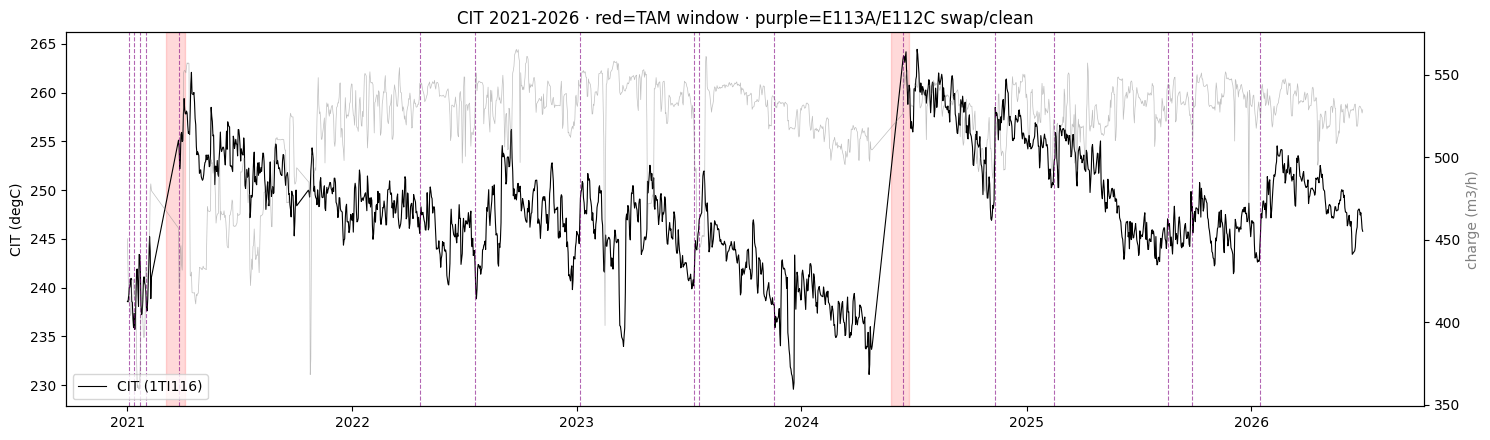

In [2]:
# clean-event dates per HX: first day of each SWITCH/TAM streak (event_type persists per run)
def clean_events(hx):
    ecol, dcol = f'{hx}_event_type', f'{hx}_days_on_duty'
    if ecol not in feat.columns: return []
    is_ev = feat[ecol].isin(['SWITCH', 'TAM']) & (feat[dcol] == 0)
    starts = is_ev & ~is_ev.shift(1, fill_value=False)
    return [(ts, feat.loc[ts, ecol]) for ts in feat.index[starts]]

e113_events = clean_events('E113A')
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(cit.index, cit.values, color='k', lw=.8, label='CIT (1TI116)')
ax2 = ax.twinx(); ax2.plot(charge.index, charge.values, color='grey', lw=.5, alpha=.5)
ax2.set_ylabel('charge (m3/h)', color='grey')
for d in TAM_DATES: ax.axvspan(d - pd.Timedelta(days=20), d + pd.Timedelta(days=10), color='red', alpha=.15)
for ts, _ in e113_events: ax.axvline(ts, color='purple', lw=.8, ls='--', alpha=.6)
ax.set_ylabel('CIT (degC)'); ax.set_title('CIT 2021-2026 · red=TAM window · purple=E113A/E112C swap/clean')
ax.legend(loc='lower left'); plt.tight_layout(); plt.savefig(FIG / '1_cit_full_history.png', dpi=110); plt.show()

## 2) SOR/EOR ต่อรอบ (E113A cleaning cycles)

แบ่ง CIT เป็นรอบตามเหตุการณ์ล้าง/สลับ E113A แล้ววัดต่อรอบ:
- **SOR** (Start of Run) = median CIT 14 วันแรกของรอบ
- **EOR** (End of Run) = median CIT 14 วันสุดท้ายของรอบ
- **decay rate** = slope เชิงเส้นของ CIT ตลอดรอบ (°C/เดือน) — ค่าที่สไลด์โรงงานใช้ 0.33-0.5°C/เดือน
- **ΔCIT ที่การล้างถัดไป** = SOR(รอบใหม่) − EOR(รอบเก่า) — คือ "คืน CIT" ที่วัดจริง

In [3]:
W = 14  # SOR/EOR median window (days)
# merge event starts that are too close together (< MIN_EVENT_GAP_DAYS) before building cycle
# bounds -- raw clean_events() has no minimum-gap filter, so two detections a few days apart
# (e.g. a data blip right after a real switch) fragment the timeline into spurious short cycles
# clustered together, which is what made SOR/EOR labels collide in dense periods. 21 days matches
# the len(seg)<21 floor already used below; cross-checked against Fouling_Rate_By_Run.csv (notebook
# 04's more careful min_span_days=30 gate) -- 11/13 boundaries already agree, this merges the 2 that don't.
MIN_EVENT_GAP_DAYS = 21
_raw_events = [ts for ts, _ in e113_events]
_merged, _last = [], None
for _ts in _raw_events:
    if _last is None or (_ts - _last).days >= MIN_EVENT_GAP_DAYS:
        _merged.append(_ts); _last = _ts
_merged_set = set(_merged)
e113_events = [(ts, ev) for ts, ev in e113_events if ts in _merged_set]

bounds = [feat.index.min()] + [ts for ts, _ in e113_events] + [feat.index.max() + pd.Timedelta(days=1)]
cycles = []
for i in range(len(bounds) - 1):
    s, e = bounds[i], bounds[i+1] - pd.Timedelta(days=1)
    seg = cit.loc[s:e].dropna()
    if len(seg) < 21: continue
    x = (seg.index - seg.index[0]).days.values.astype(float)
    slope = np.polyfit(x, seg.values, 1)[0]           # degC/day
    cycles.append(dict(start=str(s.date()), end=str(e.date()), days=int(x[-1]),
                       SOR=round(float(seg.iloc[:W].median()), 2),
                       EOR=round(float(seg.iloc[-W:].median()), 2),
                       decay_C_per_month=round(slope * 30, 3),
                       event_at_end=(e113_events[i][1] if i < len(e113_events) else None)))
cyc = pd.DataFrame(cycles)
cyc['CIT_recovered_at_next_clean'] = (cyc['SOR'].shift(-1) - cyc['EOR']).round(2)
print(cyc.to_string())
print(f"\nmedian decay: {cyc['decay_C_per_month'].median():+.2f} C/month "
      f"(plant slide: -0.33 to -0.5) · median recovery at clean: "
      f"{cyc['CIT_recovered_at_next_clean'].median():+.2f} C (plant slide: ~+2)")

         start         end  days     SOR     EOR  decay_C_per_month event_at_end  CIT_recovered_at_next_clean
0   2021-01-03  2021-01-30    27  238.87  240.37              1.513       SWITCH                        15.44
1   2021-03-25  2022-04-21   392  255.81  247.66             -0.663       SWITCH                        -0.34
2   2022-04-22  2022-07-19    88  247.32  246.34             -0.667       SWITCH                        -4.37
3   2022-07-20  2023-01-05   169  241.97  243.68             -0.151       SWITCH                         5.34
4   2023-01-06  2023-07-10   185  249.02  240.89             -0.523       SWITCH                         4.79
5   2023-07-11  2023-11-17   129  245.68  238.94             -1.832       SWITCH                        -1.95
6   2023-11-18  2024-06-13   159  236.99  233.99             -0.546          TAM                        27.35
7   2024-06-14  2024-11-10   149  261.34  249.01             -2.258       SWITCH                         8.56
8   2024-1

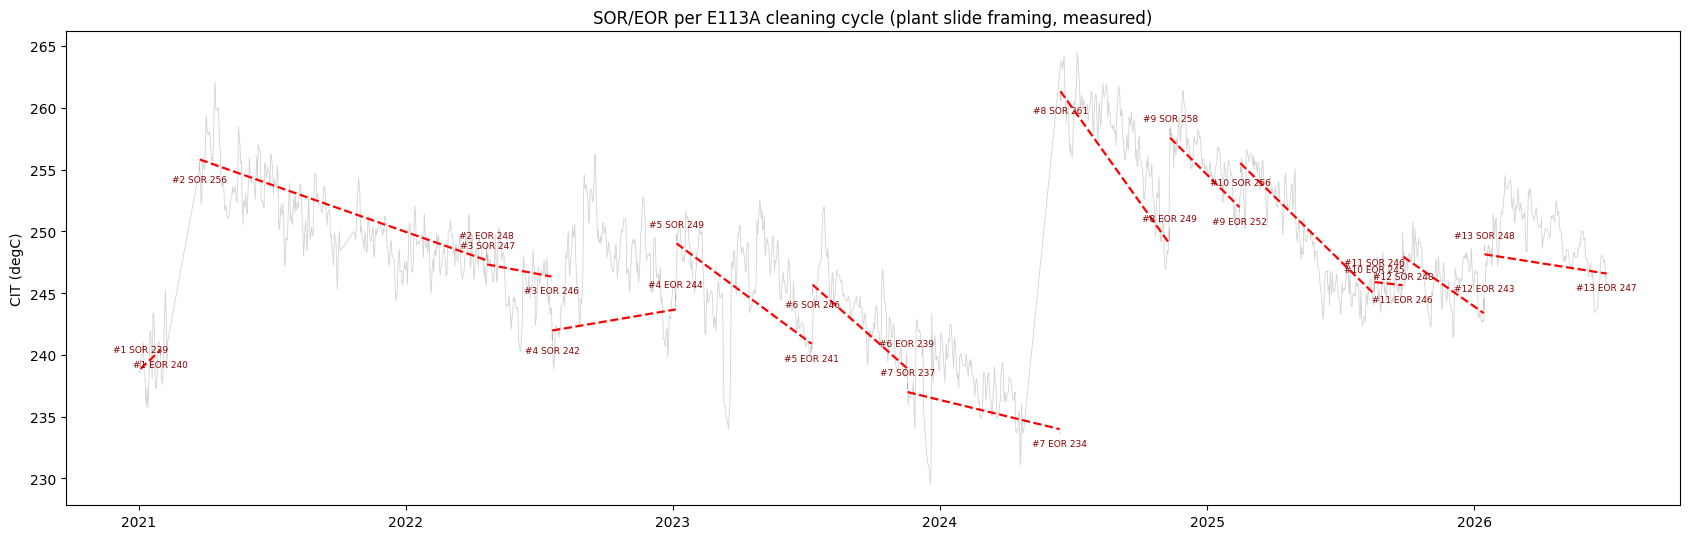

In [4]:
fig, ax = plt.subplots(figsize=(17, 5.5))   # wider/taller for label room
ax.plot(cit.index, cit.values, color='lightgrey', lw=.6)
for i, r in cyc.iterrows():
    s, e = mdates.date2num(pd.Timestamp(r['start'])), mdates.date2num(pd.Timestamp(r['end']))
    ax.plot([s, e], [r['SOR'], r['EOR']], color='red', ls='--', lw=1.6)
    # alternate vertical offset + leader line so labels don't sit exactly on top of each other in
    # dense periods (many short cycles back to back); cycle number (#N) makes which-label-belongs-
    # to-which-cycle unambiguous even where labels still land close together
    off = 12 if i % 2 == 0 else -16
    ax.annotate(f"#{i+1} SOR {r['SOR']:.0f}", (s, r['SOR']), fontsize=6.5, color='darkred',
                xytext=(0, off), textcoords='offset points', ha='center',
                arrowprops=dict(arrowstyle='-', lw=0.4, color='darkred', alpha=0.5))
    ax.annotate(f"#{i+1} EOR {r['EOR']:.0f}", (e, r['EOR']), fontsize=6.5, color='darkred',
                xytext=(0, -off), textcoords='offset points', ha='center',
                arrowprops=dict(arrowstyle='-', lw=0.4, color='darkred', alpha=0.5))
ax.set_ylabel('CIT (degC)'); ax.set_title('SOR/EOR per E113A cleaning cycle (plant slide framing, measured)')
plt.tight_layout(); plt.savefig(FIG / '2_sor_eor_cycles.png', dpi=110); plt.show()

## 3) Event study — การล้างตัวไหนคืน CIT จริง

ทุกเหตุการณ์ล้างของทุก HX: เทียบ median CIT 10 วันก่อน vs 10 วันหลัง (เว้น 2 วันรอบเหตุการณ์
กัน transient) พร้อม Δcharge — ถ้า charge เปลี่ยนมาก ให้อ่าน ΔCIT อย่างระวัง.
HX ปลายเทรน (E113A/E112C) คาดว่าคืนชัดที่สุด; ตัวต้นเทรนส่งผลผ่านเครือข่าย (เจือจาง).

In [5]:
PRE, POST, GAP = 10, 10, 2
rows = []
for hx in HX_CONFIG:
    for ts, ev in clean_events(hx):
        pre  = cit.loc[ts - pd.Timedelta(days=PRE+GAP): ts - pd.Timedelta(days=GAP)].median()
        post = cit.loc[ts + pd.Timedelta(days=GAP): ts + pd.Timedelta(days=POST+GAP)].median()
        chg  = (charge.loc[ts + pd.Timedelta(days=GAP): ts + pd.Timedelta(days=POST+GAP)].median()
                - charge.loc[ts - pd.Timedelta(days=PRE+GAP): ts - pd.Timedelta(days=GAP)].median())
        if pd.isna(pre) or pd.isna(post): continue
        rows.append(dict(HX=hx, date=str(ts.date()), event=ev,
                         dCIT=round(float(post - pre), 2), dCharge=round(float(chg), 1)))
es = pd.DataFrame(rows).sort_values('dCIT', ascending=False)
print('Top CIT recoveries (measured):'); print(es.head(15).to_string(index=False))
summ = es.groupby('HX')['dCIT'].agg(['count', 'median']).sort_values('median', ascending=False).round(2)
print('\nmedian dCIT per HX clean:'); print(summ.to_string())

Top CIT recoveries (measured):
    HX       date  event  dCIT  dCharge
  E111 2023-03-22 SWITCH 12.78      8.1
 E113A 2024-11-11 SWITCH  8.83     10.0
E112AB 2024-11-11 SWITCH  8.83     10.0
E109AB 2023-12-23 SWITCH  8.24     11.1
  E111 2022-09-01 SWITCH  7.97     -9.8
E106AB 2026-01-20 SWITCH  5.56      6.2
 E112C 2022-08-03 SWITCH  5.45    -12.3
E107AB 2026-01-15 SWITCH  5.10      7.5
 E113A 2026-01-15 SWITCH  5.10      7.5
E112AB 2023-07-11 SWITCH  5.03    -90.9
 E113A 2023-07-11 SWITCH  5.03    -90.9
 E113A 2023-07-19 SWITCH  5.00    -40.7
E112AB 2023-01-06 SWITCH  4.69     20.2
 E113A 2023-01-06 SWITCH  4.69     20.2
 E112C 2025-02-17 SWITCH  4.59      3.3

median dCIT per HX clean:
        count  median
HX                   
E111        3    7.97
E109AB      5    2.15
E112AB      8    2.13
E113A      15    0.82
E107AB     14    0.16
E105AB      1   -0.12
E102        4   -0.38
E101CD      1   -0.62
E108AB      4   -0.82
E112C      11   -1.02
E106AB      3   -1.05
E103AB      6   

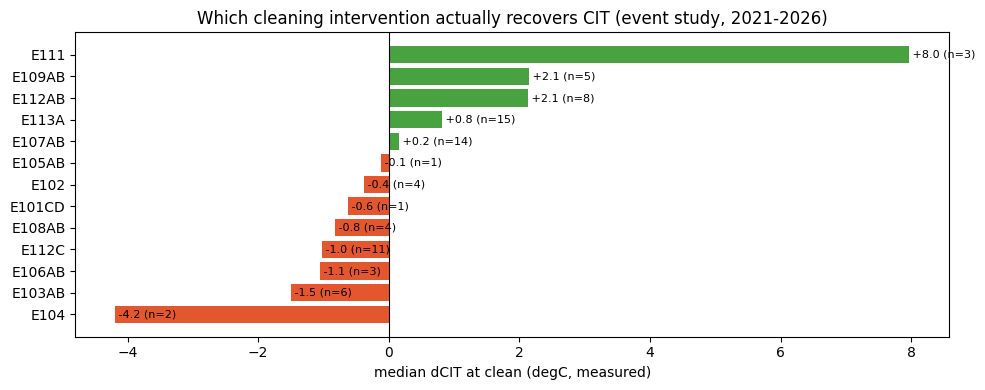

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
s2 = summ.sort_values('median')
ax.barh(s2.index, s2['median'], color=['#48A23F' if v > 0 else '#E4572E' for v in s2['median']])
ax.axvline(0, color='k', lw=.8); ax.set_xlabel('median dCIT at clean (degC, measured)')
ax.set_title('Which cleaning intervention actually recovers CIT (event study, 2021-2026)')
for i, (hx, r) in enumerate(s2.iterrows()):
    ax.text(r['median'], i, f" {r['median']:+.1f} (n={int(r['count'])})", va='center', fontsize=8)
plt.tight_layout(); plt.savefig(FIG / '3_event_study_dcit.png', dpi=110); plt.show()

## 4) จุดที่ CIT ตกแรงสุด + attribution ตามเครือข่าย HX

หา 10 ช่วง 30 วันที่ CIT ร่วงแรงสุด แล้วดูว่า HX ตัวไหน U_relative ร่วงพร้อมกัน
(ผู้ต้องสงสัยหลักของการตกครั้งนั้น) — ใช้ตำแหน่งในเทรนจาก cpht_config.

In [7]:
roll = cit.rolling(30).mean()
drop30 = roll.diff(30)                                # change of 30d-mean over 30d
worst = drop30.nsmallest(60)
# de-duplicate overlapping windows (keep worst per ~45d)
picked = []
for ts, v in worst.items():
    if all(abs((ts - p[0]).days) > 45 for p in picked):
        picked.append((ts, v))
    if len(picked) >= 8: break
att_rows = []
for ts, v in picked:
    s, e = ts - pd.Timedelta(days=30), ts
    culprits = []
    for hx in CPHT_2_HX:
        ucol = f'{hx}_U_relative'
        if ucol not in feat.columns: continue
        du = feat[ucol].loc[s:e].dropna()
        if len(du) > 10:
            d = du.iloc[-1] - du.iloc[0]
            if d < -0.05: culprits.append((hx, round(float(d), 3)))
    culprits.sort(key=lambda t: t[1])
    att_rows.append(dict(window_end=str(ts.date()), CIT_drop_30d=round(float(v), 2),
                         culprits=[f'{h} ({d:+.2f})' for h, d in culprits[:4]]))
worst_df = pd.DataFrame(att_rows)
print(worst_df.to_string(index=False))

window_end  CIT_drop_30d                                                       culprits
2023-03-20         -5.94 [E111 (-0.68), E109AB (-0.28), E103AB (-0.14), E107AB (-0.13)]
2024-11-10         -5.07 [E112C (-0.26), E111 (-0.08), E107AB (-0.06), E110ABC (-0.05)]
2023-07-10         -4.73                               [E112AB (-0.14), E109AB (-0.10)]
2023-11-29         -4.49                                                             []
2023-01-07         -4.24                                                             []
2025-06-23         -4.22  [E108AB (-0.25), E112AB (-0.09), E113A (-0.07), E111 (-0.06)]


## 5) Rf(t) — fouling resistance มาตรฐานต่อ HX

`Rf = 1/U − 1/U_clean_run` (คำนวณแล้วใน notebook 2 → คอลัมน์ `{HX}_Rf_run`) —
ตัวเลข fouling ที่ **ไม่ผันตาม flow/อุณหภูมิรายวัน** ใช้เทียบข้ามช่วงเวลา/ข้าม HX ได้ตรงกว่า CIT.

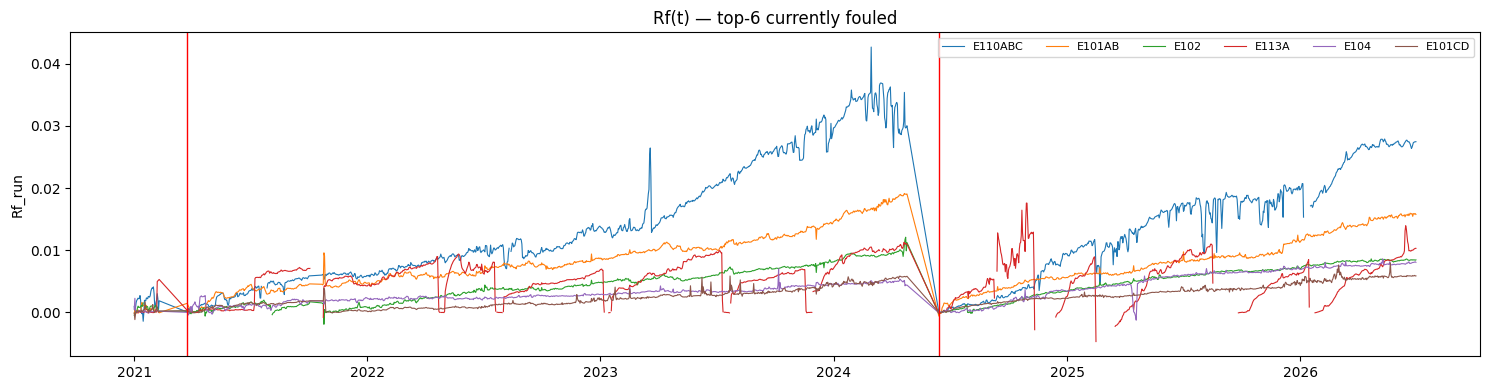

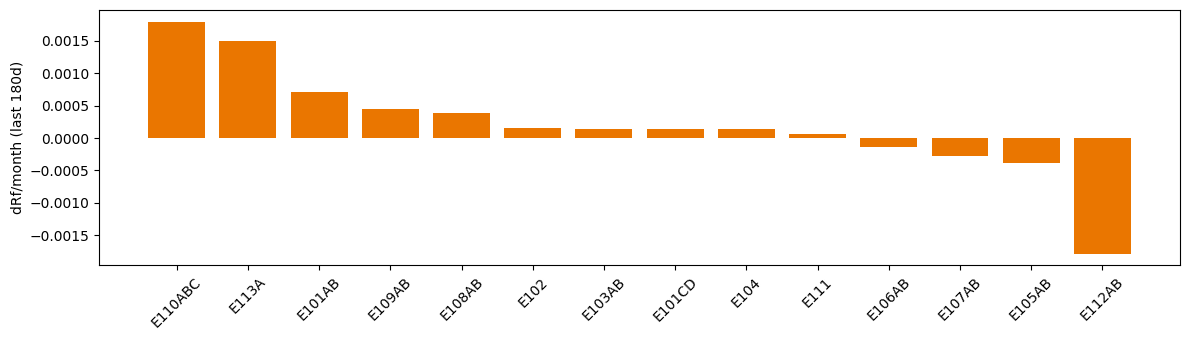

E110ABC    0.00180
E113A      0.00150
E101AB     0.00071
E109AB     0.00045
E108AB     0.00038
E102       0.00016
E103AB     0.00015
E101CD     0.00014
E104       0.00014
E111       0.00006
E106AB    -0.00013
E107AB    -0.00028
E105AB    -0.00038
E112AB    -0.00178


In [8]:
rf_cols = [c for c in feat.columns if c.endswith('_Rf_run')]
worst_rf = feat[rf_cols].iloc[-90:].median().sort_values(ascending=False)
# NOTE: keep the datetime plot and the categorical bar plot on SEPARATE figures —
# sharing an axis between a date x-axis and a string x-axis breaks matplotlib units.
fig1, ax = plt.subplots(figsize=(15, 4))
for c in worst_rf.index[:6]:
    ax.plot(feat.index, feat[c], lw=.8, label=c.replace('_Rf_run', ''))
for d in TAM_DATES: ax.axvline(mdates.date2num(d), color='red', lw=1)
ax.legend(ncol=6, fontsize=8); ax.set_ylabel('Rf_run'); ax.set_title('Rf(t) — top-6 currently fouled')
plt.tight_layout(); plt.savefig(FIG / '5a_rf_timeseries.png', dpi=110); plt.show()

rate = {}
for c in rf_cols:
    s = feat[c].iloc[-180:].dropna()
    if len(s) > 30:
        rate[c.replace('_Rf_run', '')] = np.polyfit((s.index - s.index[0]).days, s.values, 1)[0] * 30
rate = pd.Series(rate).sort_values(ascending=False)
fig2, ax2 = plt.subplots(figsize=(12, 3.5))
ax2.bar(rate.index, rate.values, color='#EA7600'); ax2.set_ylabel('dRf/month (last 180d)')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(FIG / '5b_rf_rate.png', dpi=110); plt.show()
print(rate.round(5).to_string())

## 6) Export `tam_analysis.json` สำหรับ dashboard

In [9]:
out = dict(
    as_of=str(feat.index.max().date()),
    range=[str(feat.index.min().date()), str(feat.index.max().date())],
    tam_dates=[str(d.date()) for d in TAM_DATES],
    cycles=cyc.to_dict('records'),
    median_decay_C_per_month=float(cyc['decay_C_per_month'].median()),
    median_recovery_C=float(cyc['CIT_recovered_at_next_clean'].median()) if cyc['CIT_recovered_at_next_clean'].notna().any() else None,
    event_study=es.to_dict('records'),
    event_study_summary=[dict(HX=h, n=int(r['count']), median_dCIT=float(r['median'])) for h, r in summ.iterrows()],
    worst_drops=worst_df.to_dict('records'),
    rf_rate_per_month={k: round(float(v), 5) for k, v in rate.items()},
    cit_series=dict(dates=[d.strftime('%Y-%m-%d') for d in cit.iloc[::3].index],
                    cit=[None if pd.isna(v) else round(float(v), 1) for v in cit.iloc[::3]]),
    basis='SOR/EOR = median CIT 14 วันแรก/ท้ายของรอบ E113A · decay = slope เชิงเส้นตลอดรอบ · '
          'event study = median CIT 10 วันหลัง − 10 วันก่อน (เว้น 2 วัน transient) · Rf = 1/U − 1/U_clean_run',
)

def _clean(o):   # NaN/inf are valid in Python json.dumps but break browser JSON.parse -> null them
    if isinstance(o, dict):  return {k: _clean(v) for k, v in o.items()}
    if isinstance(o, list):  return [_clean(v) for v in o]
    if isinstance(o, float) and not np.isfinite(o):  return None
    return o

OUT.write_text(json.dumps(_clean(out), ensure_ascii=False, separators=(',', ':')), encoding='utf-8')
print(f'wrote {OUT} ({OUT.stat().st_size // 1024} KB) · {len(cyc)} cycles, {len(es)} clean events')

wrote C:\Desktop\Bangchak Internship 2026\furnace-optimization\dashboard\data\tam_analysis.json (21 KB) · 13 cycles, 77 clean events
